In [ ]:
import time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim
from sklearn.decomposition import PCA
from scipy.stats import norm
warnings.filterwarnings("ignore")

SEED = 42
keras.utils.set_random_seed(SEED)
rng = np.random.default_rng(SEED)

N_TRAIN, N_TEST = 10000, 2000      # use 60000, 10000 for full MNIST
EPOCHS, BATCH   = 20, 128
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train: (10000, 28, 28, 1)  test: (2000, 28, 28, 1)  range: 0.0 1.0
A batch of 32 images has shape (32, 28, 28, 1)


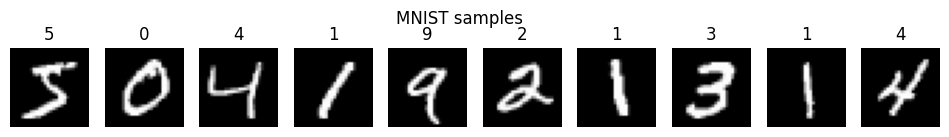

In [ ]:
(x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
x_tr = (x_tr[:N_TRAIN].astype("float32") / 255.0)[..., None]   # [0,255] -> [0,1], shape (N,28,28,1)
x_te = (x_te[:N_TEST ].astype("float32") / 255.0)[..., None]
y_tr, y_te = y_tr[:N_TRAIN], y_te[:N_TEST]
print("train:", x_tr.shape, " test:", x_te.shape, " range:", x_tr.min(), x_tr.max())
print("A batch of 32 images has shape", x_tr[:32].shape)

fig, ax = plt.subplots(1, 10, figsize=(12, 1.6))
for i in range(10):
    ax[i].imshow(x_tr[i].squeeze(), cmap="gray"); ax[i].set_title(int(y_tr[i])); ax[i].axis("off")
plt.suptitle("MNIST samples"); plt.show()

In [ ]:
# ---------- metrics ----------
def per_image_mse(x, xh):  return np.mean((x - xh) ** 2, axis=(1, 2, 3))
def ssim_per_image(x, xh): return np.array([ssim(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xh)])
def evaluate(x, xh):
    return dict(MSE=float(np.mean((x - xh) ** 2)),
                MAE=float(np.mean(np.abs(x - xh))),
                SSIM=float(ssim_per_image(x, xh).mean()))

def predict(model, x): return model.predict(x, batch_size=256, verbose=0)

# ---------- training ----------
def train(model, x_in, x_out, epochs=EPOCHS, lr=1e-3, loss="binary_crossentropy"):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=loss)
    t0 = time.time()
    h = model.fit(x_in, x_out, epochs=epochs, batch_size=BATCH, validation_split=0.1,
                  shuffle=True, verbose=0)
    return h.history, time.time() - t0

results = {}   # consolidated results table
def register(name, model, xh, t, x=None):
    x = x_te if x is None else x
    r = evaluate(x, xh); r["Parameters"] = model.count_params(); r["Time (s)"] = round(t, 1)
    results[name] = r
    return r

# ---------- plotting ----------
def show_rows(rows, titles, n=10, cmaps=None, scale=1.25, suptitle=None):
    cmaps = cmaps or ["gray"] * len(rows)
    fig, axes = plt.subplots(len(rows), n, figsize=(n * scale, len(rows) * scale + 0.5))
    axes = np.atleast_2d(axes)
    for r in range(len(rows)):
        for i in range(n):
            axes[r, i].imshow(np.squeeze(rows[r][i]), cmap=cmaps[r], vmin=0, vmax=1)
            axes[r, i].axis("off")
        axes[r, 0].set_title(titles[r], fontsize=9, loc="left")
    if suptitle: fig.suptitle(suptitle, y=1.0)
    plt.tight_layout(); plt.show()

def show_grid(imgs, nrow, ncol, title="", scale=0.9):
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * scale, nrow * scale))
    for a, im in zip(np.ravel(axes), imgs):
        a.imshow(np.squeeze(im), cmap="gray", vmin=0, vmax=1); a.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

def plot_history(hist, title, keys=("loss", "val_loss"), ylabel="Reconstruction loss"):
    plt.figure(figsize=(6, 4))
    for k in keys: plt.plot(np.arange(1, len(hist[k]) + 1), hist[k], label=k.replace("_", " "))
    plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.title(title); plt.legend(); plt.grid(alpha=.3); plt.show()

idx10 = np.arange(10)      # fixed test images used in the comparison figures

In [ ]:
def build_fc_ae(latent_dim=16):
    inp = keras.Input((28, 28, 1))
    x = layers.Flatten()(inp)                                  # 28*28 = 784
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(32,  activation="relu")(x)
    z = layers.Dense(latent_dim, name="latent")(x)
    x = layers.Dense(32,  activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(784, activation="sigmoid")(x)
    out = layers.Reshape((28, 28, 1))(x)
    return keras.Model(inp, out, name=f"fc_ae_z{latent_dim}")

fc_ae = build_fc_ae(16)
fc_ae.summary()
hist_fc, t_fc = train(fc_ae, x_tr, x_tr)
xh_fc = predict(fc_ae, x_te)
print(f"Training time: {t_fc:.1f}s")

Model: "fc_ae_z16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Training time: 12.6s


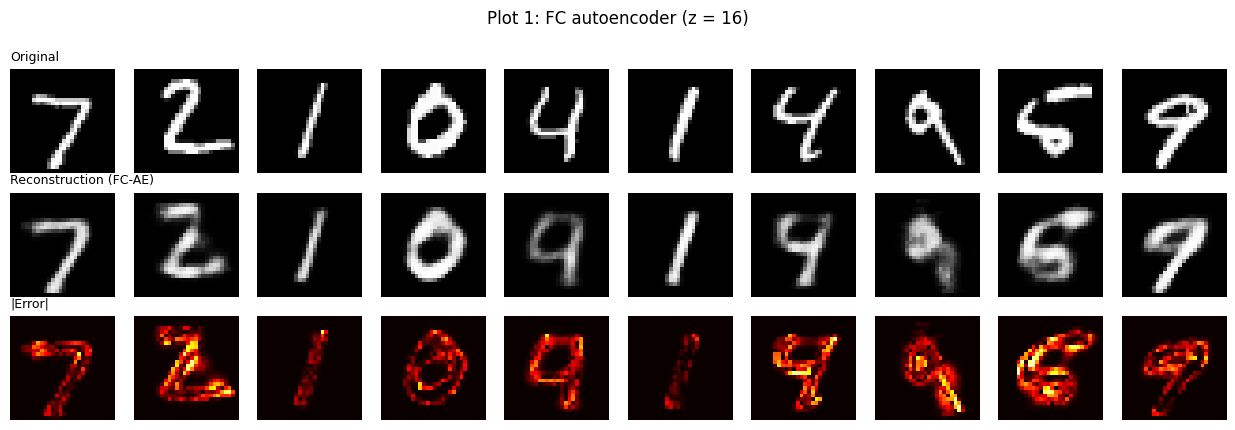

In [ ]:
err_fc = np.abs(x_te - xh_fc)
show_rows([x_te[idx10], xh_fc[idx10], err_fc[idx10]],
          ["Original", "Reconstruction (FC-AE)", "|Error|"], cmaps=["gray", "gray", "hot"],
          suptitle="Plot 1: FC autoencoder (z = 16)")

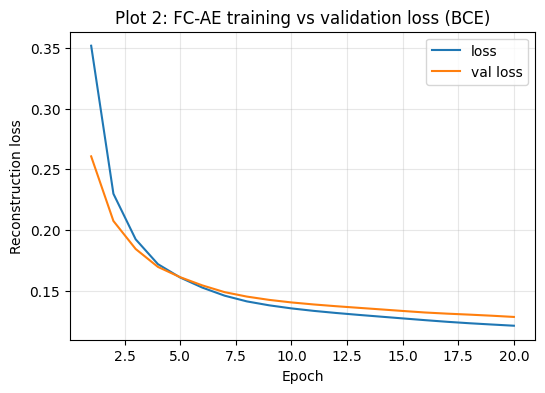

Final train loss 0.1213 | final val loss 0.1285 | gap +0.0072
Loss change over last 5 epochs (train): 0.0060  -> still decreasing (not fully converged)
Best val epoch: 20 of 20 -> no clear overfitting


In [ ]:
plot_history(hist_fc, "Plot 2: FC-AE training vs validation loss (BCE)")
tr, va = hist_fc["loss"], hist_fc["val_loss"]
print(f"Final train loss {tr[-1]:.4f} | final val loss {va[-1]:.4f} | gap {va[-1]-tr[-1]:+.4f}")
print(f"Loss change over last 5 epochs (train): {tr[max(-6, -len(tr))]-tr[-1]:.4f}  -> "
      f"{'still decreasing (not fully converged)' if tr[max(-6, -len(tr))]-tr[-1] > 0.002 else 'essentially converged'}")
print("Best val epoch:", int(np.argmin(va)) + 1, "of", len(va),
      "->", "possible overfitting (val rises after best epoch)" if np.argmin(va) < len(va) - 3 else "no clear overfitting")

In [ ]:
r = register("FC Autoencoder", fc_ae, xh_fc, t_fc)
pd.DataFrame({"Metric": ["Test MSE", "Test MAE", "Mean SSIM"], "Value": [r["MSE"], r["MAE"], r["SSIM"]]}).round(5)

,Metric,Value
0,Test MSE,0.02135
1,Test MAE,0.05661
2,Mean SSIM,0.74943


Model: "cae_None_upsampling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

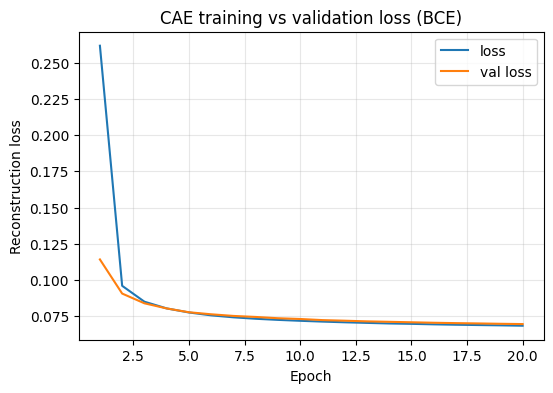

In [ ]:
def build_cae(latent_dim=None, decoder="upsampling"):
    # latent_dim=None -> spec architecture (feature-map latent). Otherwise a dense bottleneck of size latent_dim.
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    if latent_dim is None:
        x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    else:
        x = layers.Flatten()(x)
        x = layers.Dense(latent_dim, name="latent")(x)
        x = layers.Dense(7 * 7 * 64, activation="relu")(x)
        x = layers.Reshape((7, 7, 64))(x)
    if decoder == "upsampling":
        x = layers.UpSampling2D(2)(x)
        x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
        x = layers.UpSampling2D(2)(x)
    else:   # transposed convolutions
        x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
        x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    return keras.Model(inp, out, name=f"cae_{latent_dim}_{decoder}")

cae = build_cae()
cae.summary()
hist_cae, t_cae = train(cae, x_tr, x_tr)
xh_cae = predict(cae, x_te)
register("Conv. Autoencoder", cae, xh_cae, t_cae)
plot_history(hist_cae, "CAE training vs validation loss (BCE)")

In [ ]:
pd.DataFrame(results).T.loc[["FC Autoencoder", "Conv. Autoencoder"], ["MSE", "MAE", "SSIM", "Parameters"]].round(5)

,MSE,MAE,SSIM,Parameters
FC Autoencoder,0.02135,0.05661,0.74943,211040.0
Conv. Autoencoder,0.00259,0.01499,0.97397,74497.0


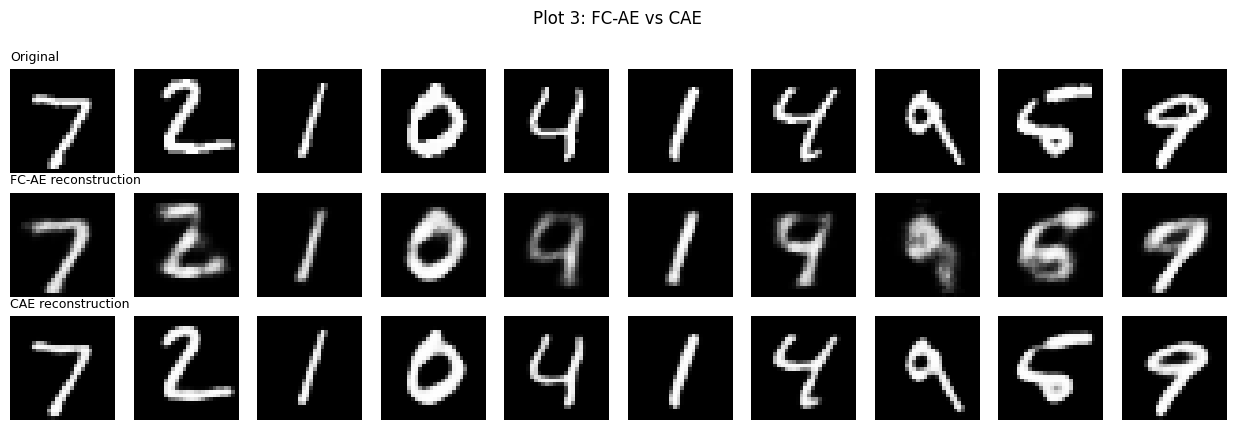

In [ ]:
show_rows([x_te[idx10], xh_fc[idx10], xh_cae[idx10]],
          ["Original", "FC-AE reconstruction", "CAE reconstruction"],
          suptitle="Plot 3: FC-AE vs CAE")

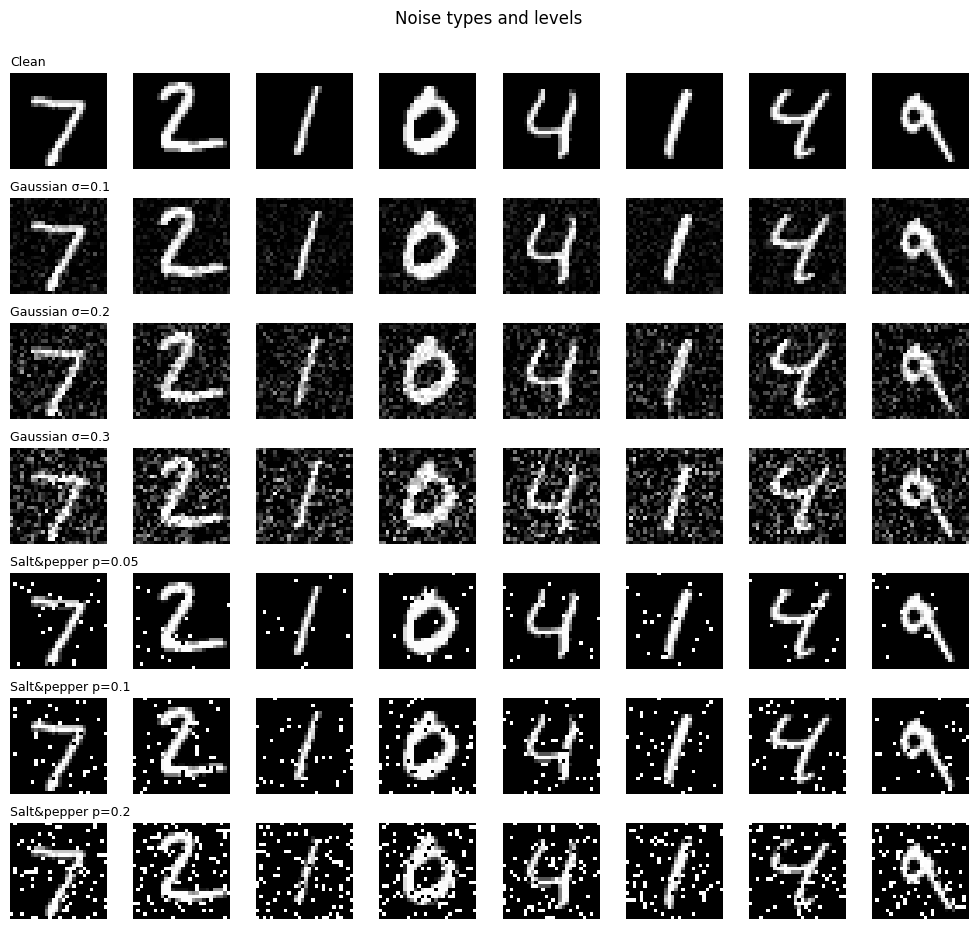

In [ ]:
def add_gaussian(x, sigma, g):
    return np.clip(x + g.normal(0.0, sigma, x.shape), 0.0, 1.0).astype("float32")

def add_saltpepper(x, p, g):
    xn = x.copy(); r = g.random(x.shape)
    xn[r < p / 2] = 0.0                      # pepper
    xn[(r >= p / 2) & (r < p)] = 1.0         # salt
    return xn

def add_noise(x, kind, level, g):
    return add_gaussian(x, level, g) if kind == "gaussian" else add_saltpepper(x, level, g)

LEVELS = {"gaussian": [0.1, 0.2, 0.3], "saltpepper": [0.05, 0.10, 0.20]}
train_rng = np.random.default_rng(1)
test_rng  = np.random.default_rng(2)
noisy_test = {(k, l): add_noise(x_te, k, l, test_rng) for k in LEVELS for l in LEVELS[k]}

# noise preview
rows = [x_te[:8]] + [noisy_test[("gaussian", l)][:8] for l in LEVELS["gaussian"]] + \
       [noisy_test[("saltpepper", l)][:8] for l in LEVELS["saltpepper"]]
show_rows(rows, ["Clean"] + [f"Gaussian σ={l}" for l in LEVELS["gaussian"]] +
                [f"Salt&pepper p={l}" for l in LEVELS["saltpepper"]], n=8, suptitle="Noise types and levels")

trained DAE  gaussian   level=0.1  (29s)
trained DAE  gaussian   level=0.2  (23s)
trained DAE  gaussian   level=0.3  (23s)
trained DAE  saltpepper level=0.05  (22s)
trained DAE  saltpepper level=0.1  (22s)
trained DAE  saltpepper level=0.2  (21s)


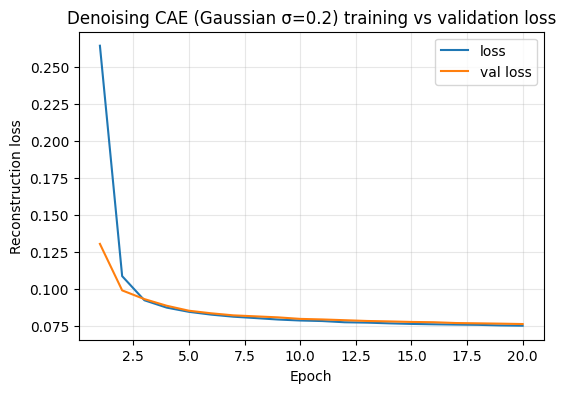

In [ ]:
def train_dae(kind, level, epochs=EPOCHS, builder=build_cae):
    model = builder()
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    hist = {"loss": [], "val_loss": []}; t0 = time.time()
    for _ in range(epochs):
        xn = add_noise(x_tr, kind, level, train_rng)               # fresh noise each epoch
        h = model.fit(xn, x_tr, epochs=1, batch_size=BATCH, validation_split=0.1, verbose=0)
        for k in hist: hist[k].append(h.history[k][0])
    return dict(model=model, hist=hist, time=time.time() - t0)

dae = {}
for kind in LEVELS:
    for lvl in LEVELS[kind]:
        dae[(kind, lvl)] = train_dae(kind, lvl)
        print(f"trained DAE  {kind:10s} level={lvl}  ({dae[(kind, lvl)]['time']:.0f}s)")

MAIN = ("gaussian", 0.2)                       # the "Denoising CAE" used in the summary tables
main_dae = dae[MAIN]["model"]
xh_dae = predict(main_dae, noisy_test[MAIN])
register("Denoising CAE", main_dae, xh_dae, dae[MAIN]["time"])
plot_history(dae[MAIN]["hist"], "Denoising CAE (Gaussian σ=0.2) training vs validation loss")

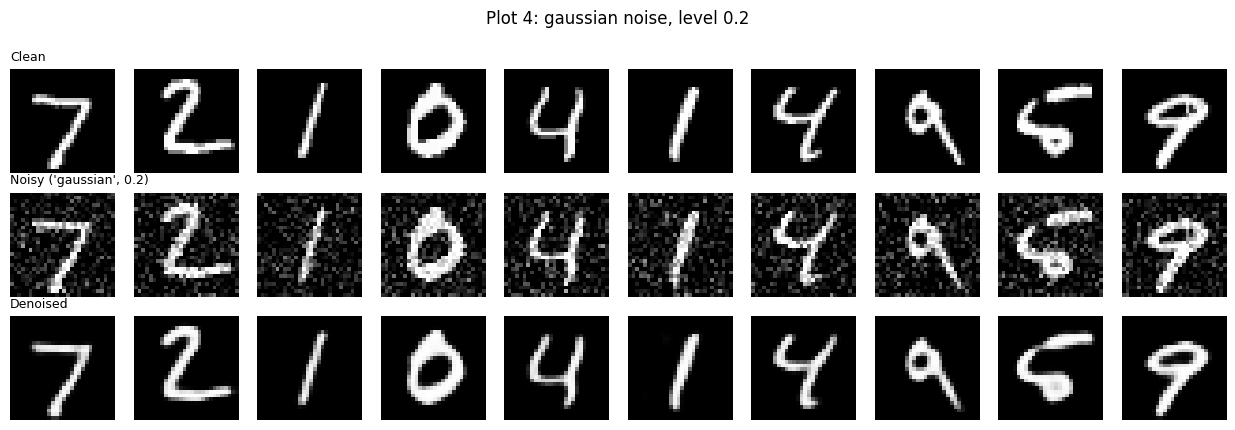

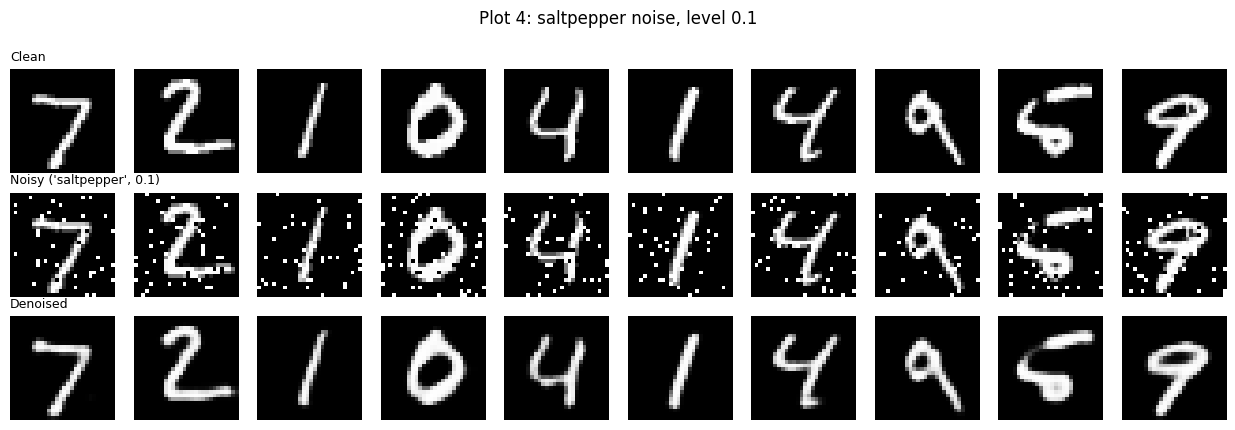

In [ ]:
for key in [("gaussian", 0.2), ("saltpepper", 0.10)]:
    xn = noisy_test[key]; xd = predict(dae[key]["model"], xn)
    show_rows([x_te[idx10], xn[idx10], xd[idx10]], ["Clean", f"Noisy {key}", "Denoised"],
              suptitle=f"Plot 4: {key[0]} noise, level {key[1]}")

,Noise level,Series,MSE,MAE,SSIM
0,0.1,Noisy input (no denoising),0.00543,0.04408,0.67889
1,0.1,DAE trained at σ=0.2,0.00347,0.01730,0.96060
2,0.1,DAE trained at matching σ,0.00335,0.01747,0.96293
3,0.2,Noisy input (no denoising),0.02122,0.08654,0.59365
4,0.2,DAE trained at σ=0.2,0.00448,0.02083,0.94659
5,0.2,DAE trained at matching σ,0.00448,0.02083,0.94659
6,0.3,Noisy input (no denoising),0.04676,0.12818,0.50914
7,0.3,DAE trained at σ=0.2,0.00686,0.02871,0.87559
8,0.3,DAE trained at matching σ,0.00684,0.02679,0.91558


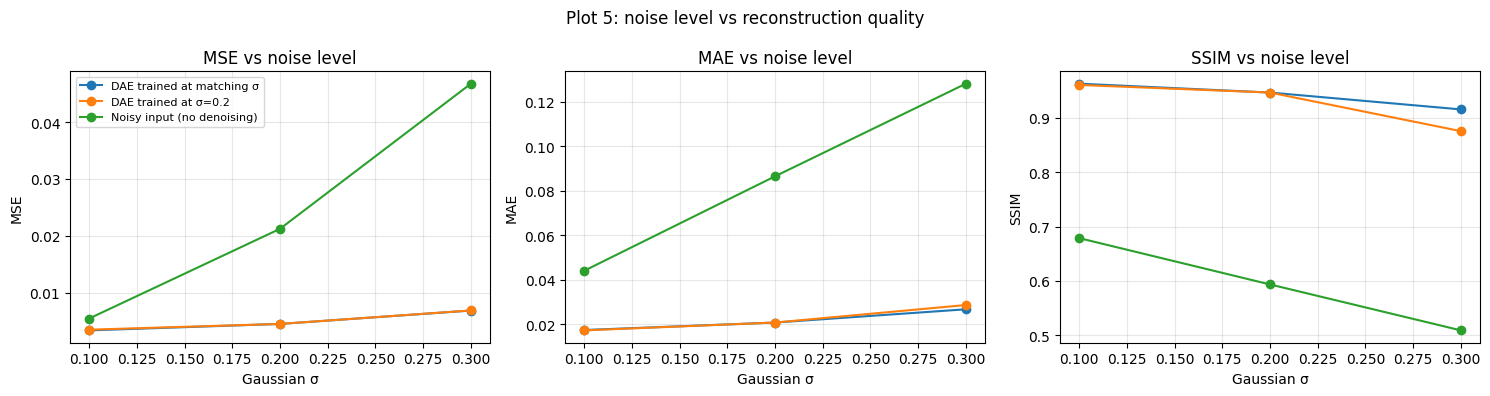

In [ ]:
rows = []
for s in LEVELS["gaussian"]:
    xn = noisy_test[("gaussian", s)]
    rows.append(dict(**{"Noise level": s, "Series": "Noisy input (no denoising)"}, **evaluate(x_te, xn)))
    rows.append(dict(**{"Noise level": s, "Series": "DAE trained at σ=0.2"},
                     **evaluate(x_te, predict(dae[("gaussian", 0.2)]["model"], xn))))
    rows.append(dict(**{"Noise level": s, "Series": "DAE trained at matching σ"},
                     **evaluate(x_te, predict(dae[("gaussian", s)]["model"], xn))))
df5 = pd.DataFrame(rows)
display(df5.round(5))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for m, a in zip(["MSE", "MAE", "SSIM"], ax):           # separate axes: incompatible scales are not mixed
    for name, g in df5.groupby("Series"):
        a.plot(g["Noise level"], g[m], marker="o", label=name)
    a.set_xlabel("Gaussian σ"); a.set_ylabel(m); a.set_title(m + " vs noise level"); a.grid(alpha=.3)
ax[0].legend(fontsize=8); plt.suptitle("Plot 5: noise level vs reconstruction quality"); plt.tight_layout(); plt.show()

In [ ]:
class Sampling(layers.Layer):
    # reparameterisation trick
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

def build_encoder(latent_dim):
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inp)   # 14x14
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)     # 7x7
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    mu     = layers.Dense(latent_dim, name="mu")(x)
    logvar = layers.Dense(latent_dim, name="log_var")(x)
    return keras.Model(inp, [mu, logvar], name="encoder")

def build_decoder(latent_dim):
    inp = keras.Input((latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(inp)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    out = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(inp, out, name="decoder")

class VAE(keras.Model):
    def __init__(self, latent_dim=2, beta=1.0, **kw):
        super().__init__(**kw)
        self.latent_dim, self.beta = latent_dim, beta
        self.encoder, self.decoder = build_encoder(latent_dim), build_decoder(latent_dim)
        self.sampling = Sampling()
        self.total_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker   = keras.metrics.Mean(name="rec_loss")
        self.kl_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self): return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def call(self, x):                       # deterministic reconstruction through the mean
        mu, _ = self.encoder(x)
        return self.decoder(mu)

    def _vae_losses(self, x):
        mu, logvar = self.encoder(x)
        z  = self.sampling([mu, logvar])
        xh = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xh), axis=(1, 2)))
        kl  = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        return rec, kl

    def _track(self, rec, kl):
        self.total_tracker.update_state(rec + self.beta * kl)
        self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            rec, kl = self._vae_losses(x)
            total = rec + self.beta * kl
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._track(rec, kl)

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        rec, kl = self._vae_losses(x)
        return self._track(rec, kl)

def train_vae(latent_dim=2, beta=1.0, epochs=EPOCHS, lr=1e-3):
    v = VAE(latent_dim, beta)
    v.compile(optimizer=keras.optimizers.Adam(lr))
    t0 = time.time()
    h = v.fit(x_tr, epochs=epochs, batch_size=BATCH, validation_split=0.1, verbose=0)
    return v, h.history, time.time() - t0

def vae_params(v): return v.encoder.count_params() + v.decoder.count_params()

def encode(v, x):
    mu, logvar = v.encoder.predict(x, batch_size=256, verbose=0)
    return mu, logvar

def vae_evaluate(v, x=None):
    x = x_te if x is None else x
    mu, logvar = encode(v, x)
    xh = np.clip(v.decoder.predict(mu, batch_size=256, verbose=0), 1e-7, 1 - 1e-7)
    rec = float(np.mean(np.sum(-(x * np.log(xh) + (1 - x) * np.log(1 - xh)), axis=(1, 2, 3))))
    kl  = float(np.mean(-0.5 * np.sum(1 + logvar - mu ** 2 - np.exp(logvar), axis=1)))
    out = dict(**{"Reconstruction Loss": rec, "KL Loss": kl, "Total Loss": rec + v.beta * kl}, **evaluate(x, xh))
    return out, xh, mu

vae, hist_vae, t_vae = train_vae(2, 1.0)
vae_res, xh_vae, mu_te = vae_evaluate(vae)
results["VAE"] = dict(MSE=vae_res["MSE"], MAE=vae_res["MAE"], SSIM=vae_res["SSIM"],
                      Parameters=vae_params(vae), **{"Time (s)": round(t_vae, 1)})
print(f"VAE trained in {t_vae:.1f}s")

VAE trained in 25.5s


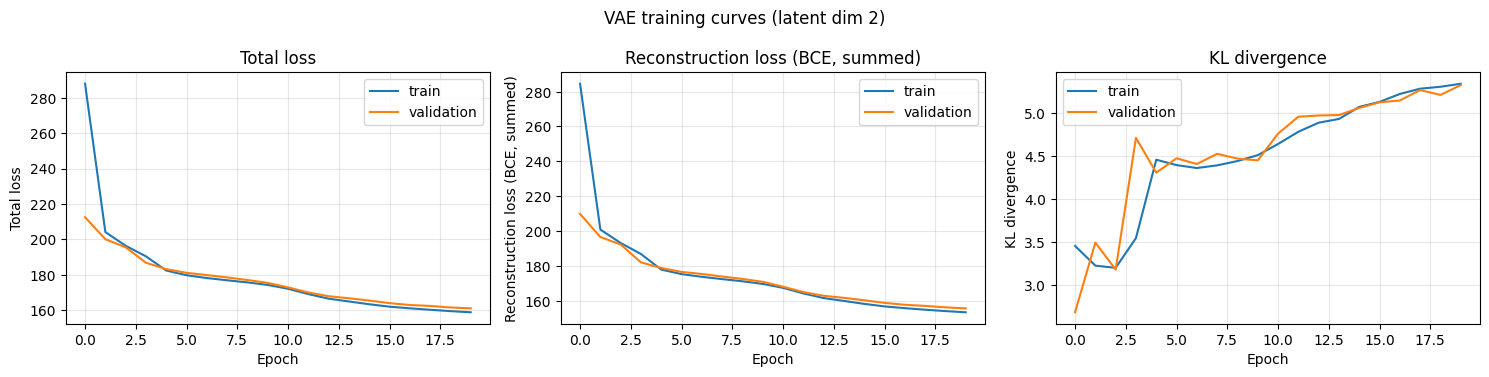

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, (k, t) in zip(ax, [("loss", "Total loss"), ("rec_loss", "Reconstruction loss (BCE, summed)"), ("kl_loss", "KL divergence")]):
    a.plot(hist_vae[k], label="train"); a.plot(hist_vae["val_" + k], label="validation")
    a.set_xlabel("Epoch"); a.set_ylabel(t); a.set_title(t); a.legend(); a.grid(alpha=.3)
plt.suptitle("VAE training curves (latent dim 2)"); plt.tight_layout(); plt.show()

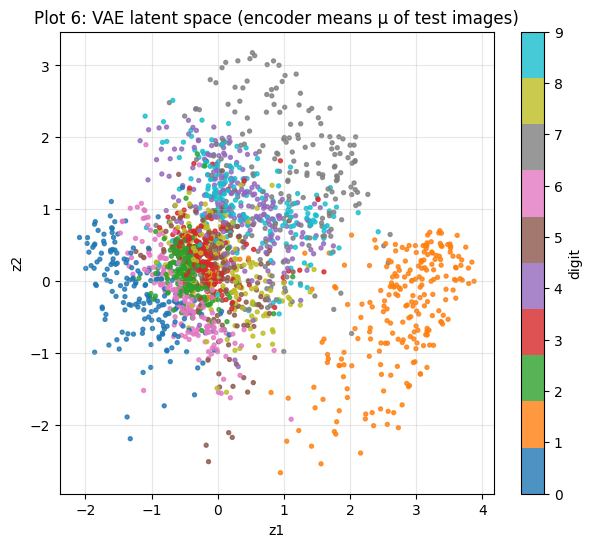

Mean μ per dim : [0.294 0.352] | std of μ per dim: [1.165 0.849]
Mean σ per dim : [0.076 0.09 ]


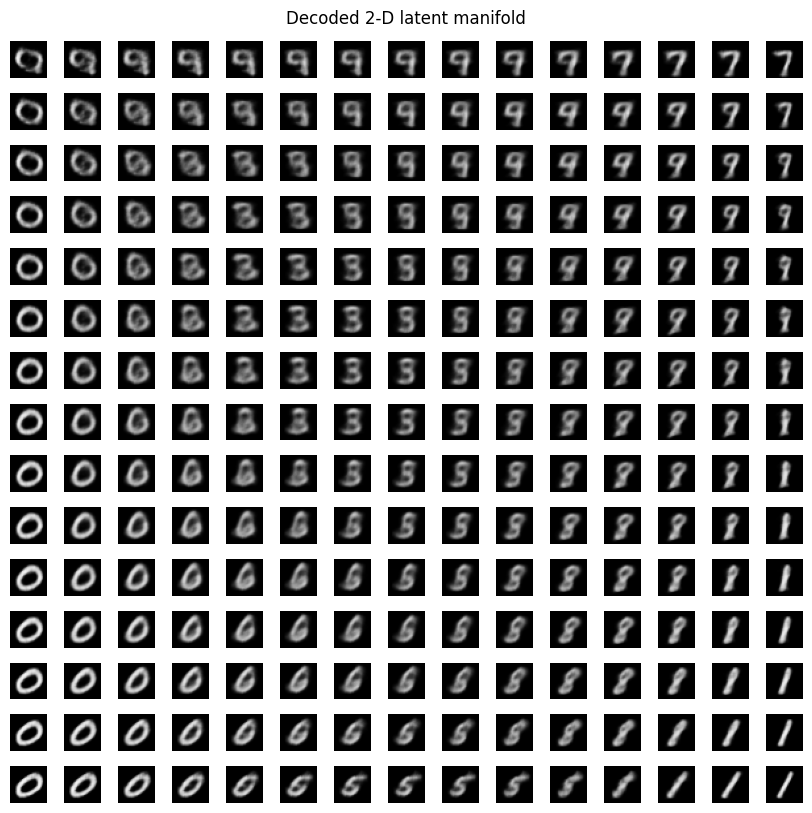

In [ ]:
def plot_latent(z, y, title, xlabel="z1", ylabel="z2"):
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(z[:, 0], z[:, 1], c=y, cmap="tab10", s=8, alpha=.8)
    plt.colorbar(sc, ticks=range(10), label="digit"); plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.title(title); plt.grid(alpha=.3); plt.show()

plot_latent(mu_te, y_te, "Plot 6: VAE latent space (encoder means μ of test images)")
_, logvar_te = encode(vae, x_te)
print("Mean μ per dim :", mu_te.mean(0).round(3), "| std of μ per dim:", mu_te.std(0).round(3))
print("Mean σ per dim :", np.exp(0.5 * logvar_te).mean(0).round(3))

def plot_manifold(decoder, n=15, title="Decoded 2-D latent manifold"):
    q = norm.ppf(np.linspace(0.03, 0.97, n))                  # quantiles of N(0,1)
    zs = np.array([[a, b] for b in q[::-1] for a in q], dtype="float32")
    imgs = decoder.predict(zs, verbose=0)
    show_grid(imgs, n, n, title, scale=0.55)
plot_manifold(vae.decoder)

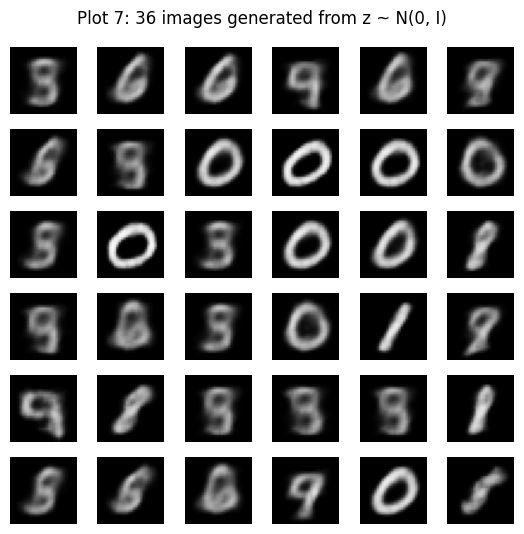

In [ ]:
z_rand = np.random.default_rng(7).standard_normal((36, 2)).astype("float32")
gen = vae.decoder.predict(z_rand, verbose=0)
show_grid(gen, 6, 6, "Plot 7: 36 images generated from z ~ N(0, I)")

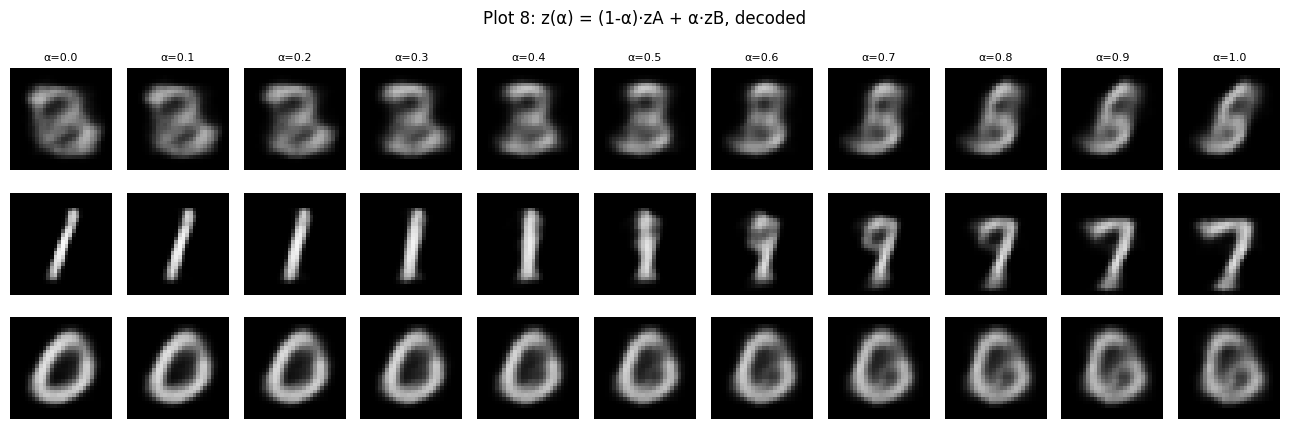

In [ ]:
def interpolate(decoder, zA, zB, steps=11):
    alphas = np.linspace(0, 1, steps)[:, None]
    z = (1 - alphas) * zA[None] + alphas * zB[None]
    return decoder.predict(z.astype("float32"), verbose=0)

def pick(digit, k=0): return np.where(y_te == digit)[0][k]
pairs = [(3, 8), (1, 7), (0, 6)]
fig, axes = plt.subplots(len(pairs), 11, figsize=(13, 1.3 * len(pairs) + 0.6))
for r, (a, b) in enumerate(pairs):
    seq = interpolate(vae.decoder, mu_te[pick(a)], mu_te[pick(b)])
    for i in range(11):
        axes[r, i].imshow(seq[i].squeeze(), cmap="gray", vmin=0, vmax=1); axes[r, i].axis("off")
        if r == 0: axes[r, i].set_title(f"α={i/10:.1f}", fontsize=8)
    axes[r, 0].set_ylabel(f"{a}→{b}")
plt.suptitle("Plot 8: z(α) = (1-α)·zA + α·zB, decoded"); plt.tight_layout(); plt.show()

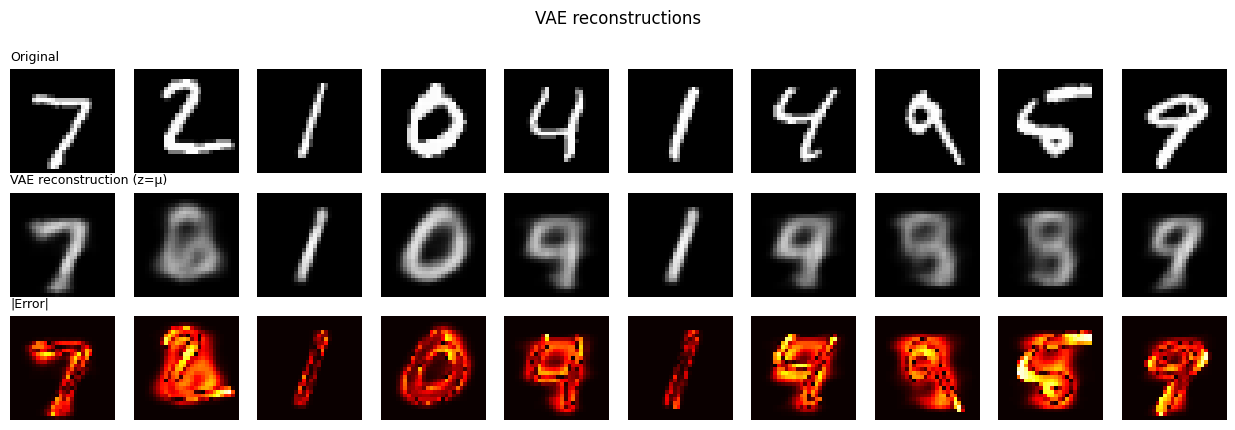

,VAE Metric,Value
0,Reconstruction Loss,152.33653
1,KL Loss,5.23594
2,Total Loss,157.57247
3,MSE,0.04545
4,MAE,0.10780
5,SSIM,0.46263


In [ ]:
show_rows([x_te[idx10], xh_vae[idx10], np.abs(x_te - xh_vae)[idx10]], ["Original", "VAE reconstruction (z=μ)", "|Error|"],
          cmaps=["gray", "gray", "hot"], suptitle="VAE reconstructions")
pd.DataFrame({"VAE Metric": list(vae_res.keys()), "Value": list(vae_res.values())}).round(5)

In [ ]:
import os
os.makedirs("high_error", exist_ok=True)

def save_high_error(e, xh, tag):
    top = np.argsort(e)[::-1][:5]
    for r, i in enumerate(top, 1):
        plt.imsave(f"high_error/{tag}_{r}_orig.png",  x_te[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.imsave(f"high_error/{tag}_{r}_recon.png", xh[i].squeeze(),  cmap="gray", vmin=0, vmax=1)

save_high_error(e_cae, xh_cae, "cae")
save_high_error(e_fc,  xh_fc,  "fc")

!zip -qr high_error.zip high_error
from google.colab import files
files.download("high_error.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cmp = pd.DataFrame(results).T.loc[["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE"], ["MSE", "MAE", "SSIM", "Parameters"]]
print("Denoising CAE is evaluated on noisy (σ=0.2) inputs vs the clean targets.")
cmp.round(5)

Denoising CAE is evaluated on noisy (σ=0.2) inputs vs the clean targets.


,MSE,MAE,SSIM,Parameters
FC Autoencoder,0.02135,0.05661,0.74943,211040.0
Conv. Autoencoder,0.00259,0.01499,0.97397,74497.0
Denoising CAE,0.00448,0.02083,0.94659,74497.0


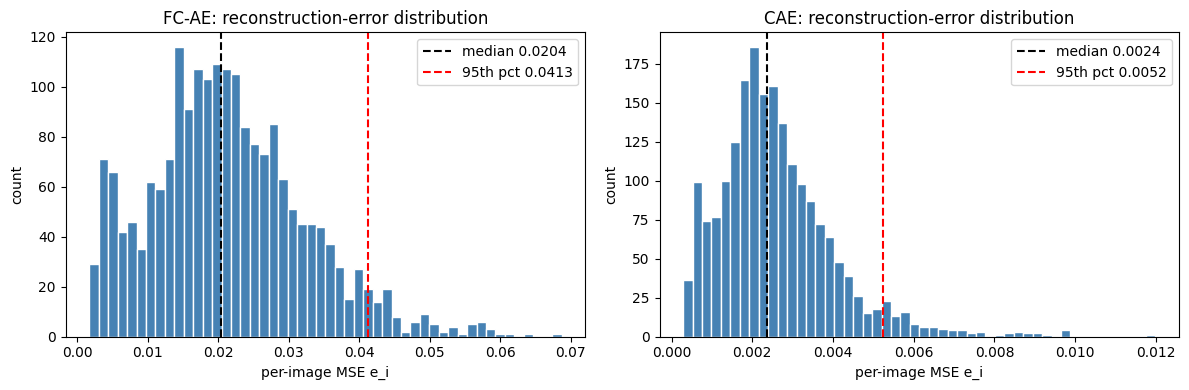

FC-AE: mean=0.02135 median=0.02036 std=0.01100 min=0.00173 max=0.06868
CAE: mean=0.00259 median=0.00237 std=0.00142 min=0.00029 max=0.01199


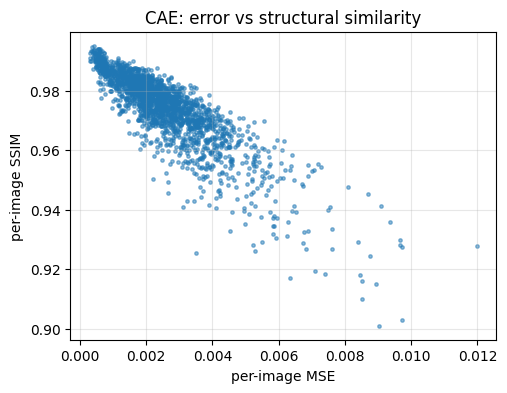

Correlation(MSE, SSIM) = -0.858


In [ ]:
e_fc, e_cae = per_image_mse(x_te, xh_fc), per_image_mse(x_te, xh_cae)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, e, n in zip(ax, [e_fc, e_cae], ["FC-AE", "CAE"]):
    a.hist(e, bins=50, color="steelblue", edgecolor="white")
    a.axvline(np.median(e), color="k", ls="--", label=f"median {np.median(e):.4f}")
    a.axvline(np.percentile(e, 95), color="r", ls="--", label=f"95th pct {np.percentile(e,95):.4f}")
    a.set_xlabel("per-image MSE e_i"); a.set_ylabel("count"); a.set_title(f"{n}: reconstruction-error distribution"); a.legend()
plt.tight_layout(); plt.show()
for n, e in [("FC-AE", e_fc), ("CAE", e_cae)]:
    print(f"{n}: mean={e.mean():.5f} median={np.median(e):.5f} std={e.std():.5f} min={e.min():.5f} max={e.max():.5f}")

# error vs. visual quality
s_cae = ssim_per_image(x_te, xh_cae)
plt.figure(figsize=(5.5, 4)); plt.scatter(e_cae, s_cae, s=6, alpha=.5)
plt.xlabel("per-image MSE"); plt.ylabel("per-image SSIM"); plt.title("CAE: error vs structural similarity")
plt.grid(alpha=.3); plt.show()
print("Correlation(MSE, SSIM) =", np.corrcoef(e_cae, s_cae)[0, 1].round(3))

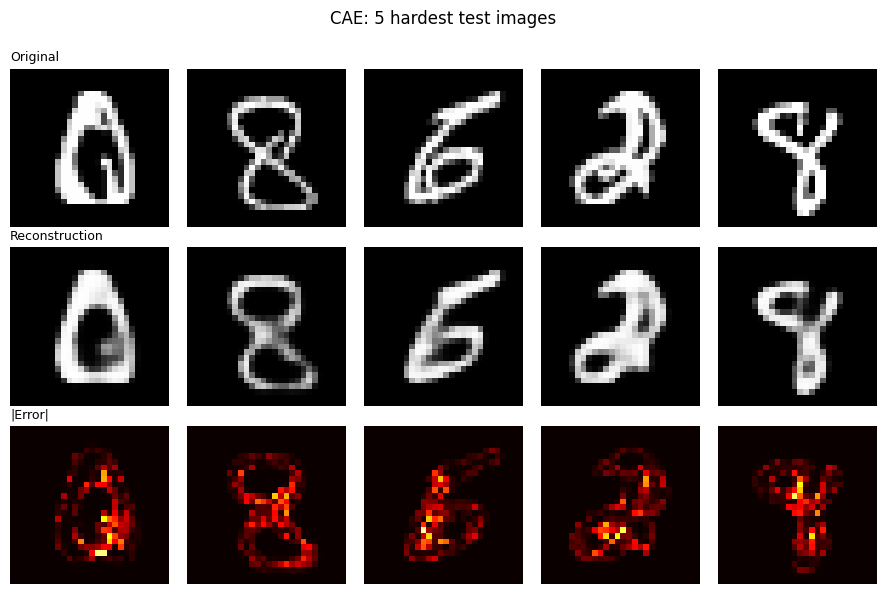

CAE | indices: [895, 431, 1982, 1395, 1125] | digits: [0, 8, 6, 2, 8] | errors: [0.012000000104308128, 0.009700000286102295, 0.009700000286102295, 0.009700000286102295, 0.009700000286102295]


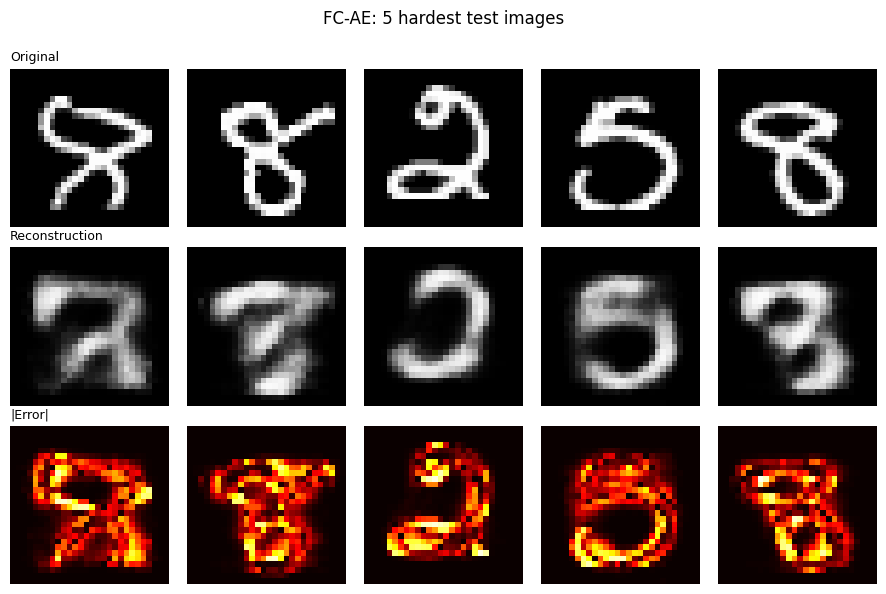

FC-AE | indices: [1782, 1170, 744, 654, 1882] | digits: [8, 8, 2, 5, 8] | errors: [0.06870000064373016, 0.06360000371932983, 0.06069999933242798, 0.059700001031160355, 0.05909999832510948]


In [ ]:
for name, e, xh in [("CAE", e_cae, xh_cae), ("FC-AE", e_fc, xh_fc)]:
    top = np.argsort(e)[::-1][:5]
    show_rows([x_te[top], xh[top], np.abs(x_te - xh)[top]], ["Original", "Reconstruction", "|Error|"], n=5,
              cmaps=["gray", "gray", "hot"], scale=1.8, suptitle=f"{name}: 5 hardest test images")
    print(name, "| indices:", top.tolist(), "| digits:", y_te[top].tolist(), "| errors:", e[top].round(4).tolist())

,Latent Dimension,MSE,SSIM,Parameters
0,2,0.04503,0.46621,210130
1,8,0.02658,0.68509,210520
2,16,0.02236,0.73745,211040
3,32,0.01891,0.77373,212080


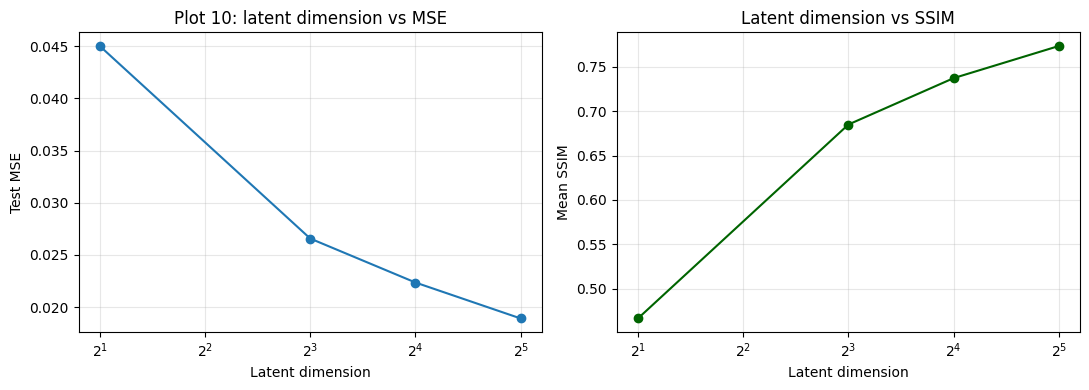

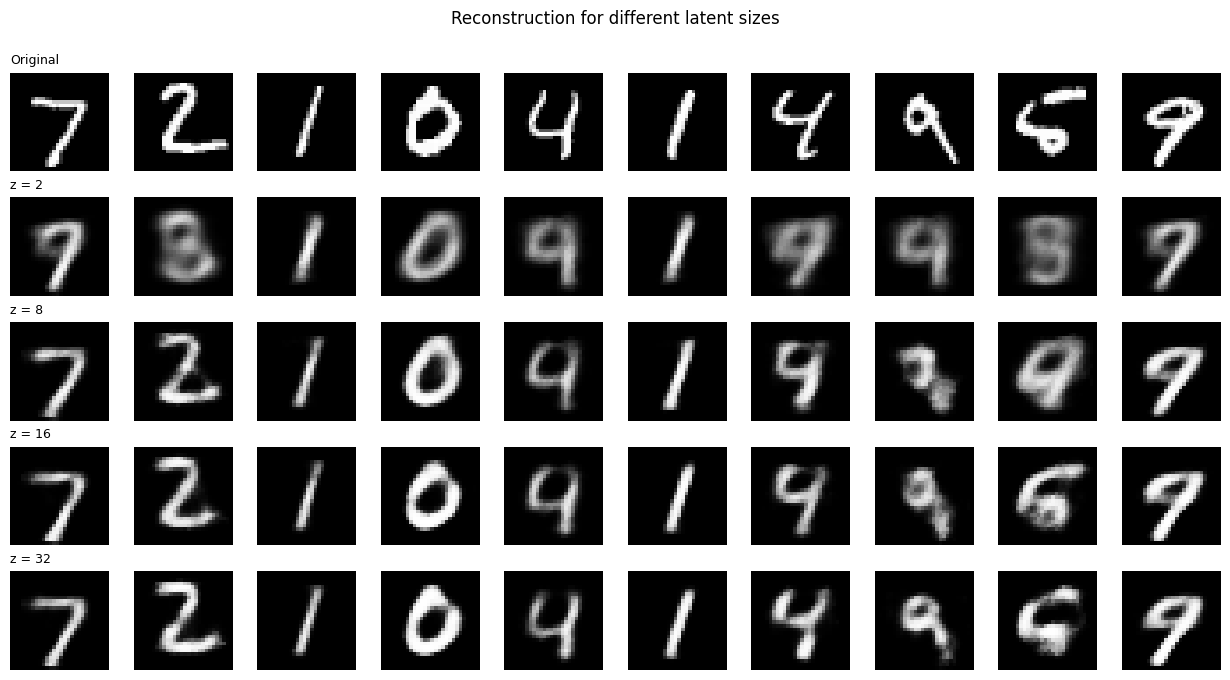

In [ ]:
dims = [2, 8, 16, 32]
ld_rows, ld_recon = [], {}
for d in dims:
    m = build_fc_ae(d); h, t = train(m, x_tr, x_tr); xh = predict(m, x_te)
    r = evaluate(x_te, xh)
    ld_rows.append({"Latent Dimension": d, "MSE": r["MSE"], "SSIM": r["SSIM"], "Parameters": m.count_params()})
    ld_recon[d] = xh
ld = pd.DataFrame(ld_rows); display(ld.round(5))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ld["Latent Dimension"], ld["MSE"], "o-"); ax[0].set_xscale("log", base=2)
ax[0].set_xlabel("Latent dimension"); ax[0].set_ylabel("Test MSE"); ax[0].set_title("Plot 10: latent dimension vs MSE"); ax[0].grid(alpha=.3)
ax[1].plot(ld["Latent Dimension"], ld["SSIM"], "o-", color="darkgreen"); ax[1].set_xscale("log", base=2)
ax[1].set_xlabel("Latent dimension"); ax[1].set_ylabel("Mean SSIM"); ax[1].set_title("Latent dimension vs SSIM"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

show_rows([x_te[idx10]] + [ld_recon[d][idx10] for d in dims], ["Original"] + [f"z = {d}" for d in dims],
          suptitle="Reconstruction for different latent sizes")

,Latent dim,MSE,MAE,SSIM,Parameters
0,4,0.03421,0.08037,0.63492,65797
1,8,0.02080,0.05381,0.77042,90889
2,16,0.01128,0.03468,0.88057,141073
3,32,0.00635,0.02436,0.93008,241441


,FC MSE,FC SSIM,CAE MSE,CAE SSIM
8,0.02658,0.68509,0.02080,0.77042
16,0.02236,0.73745,0.01128,0.88057
32,0.01891,0.77373,0.00635,0.93008


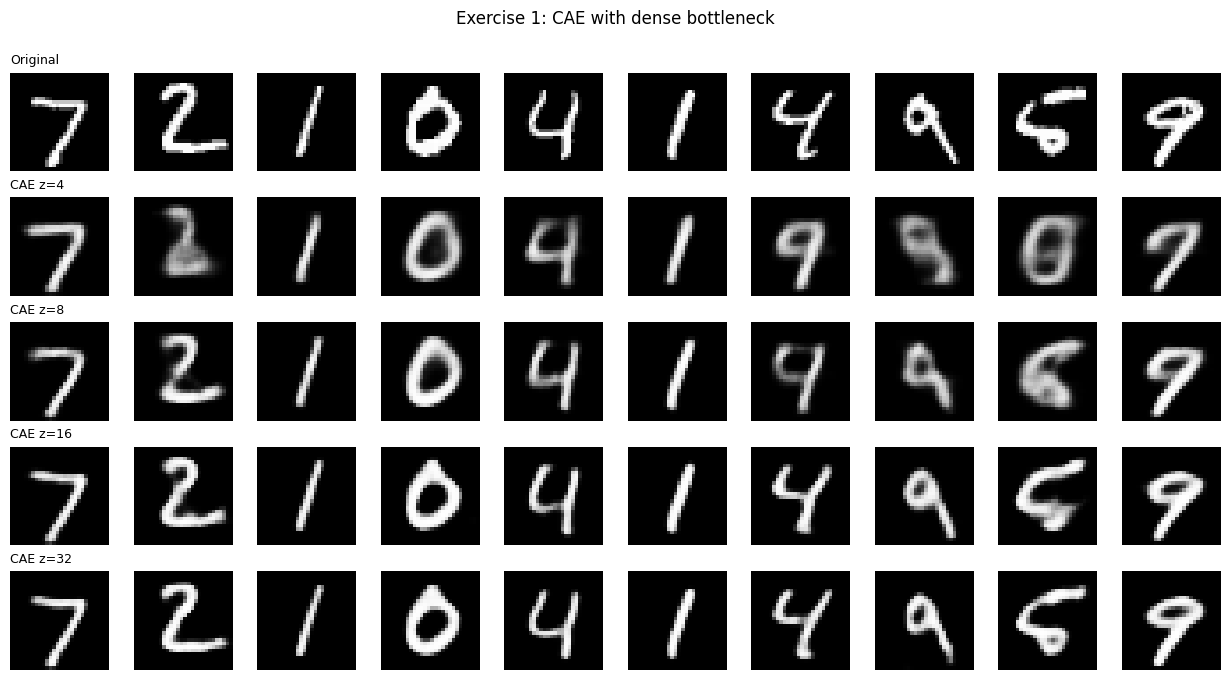

In [ ]:
ex1, ex1_recon = [], {}
for d in [4, 8, 16, 32]:
    m = build_cae(latent_dim=d); h, t = train(m, x_tr, x_tr); xh = predict(m, x_te)
    ex1.append({"Latent dim": d, **evaluate(x_te, xh), "Parameters": m.count_params()}); ex1_recon[d] = xh
ex1 = pd.DataFrame(ex1); display(ex1.round(5))
# fair comparison against FC-AE at the same latent sizes
cmp_ld = ld.set_index("Latent Dimension")[["MSE", "SSIM"]].add_prefix("FC ").join(
         ex1.set_index("Latent dim")[["MSE", "SSIM"]].add_prefix("CAE "), how="inner")
display(cmp_ld.round(5))
show_rows([x_te[idx10]] + [ex1_recon[d][idx10] for d in [4, 8, 16, 32]], ["Original"] + [f"CAE z={d}" for d in [4, 8, 16, 32]],
          suptitle="Exercise 1: CAE with dense bottleneck")

In [ ]:
gA, sA = ("gaussian", 0.2), ("saltpepper", 0.10)
rows = []
for tr_key in [gA, sA]:
    for te_key in [gA, sA]:
        xd = predict(dae[tr_key]["model"], noisy_test[te_key])
        rows.append({"Trained on": f"{tr_key[0]} {tr_key[1]}", "Tested on": f"{te_key[0]} {te_key[1]}", **evaluate(x_te, xd)})
display(pd.DataFrame(rows).round(5))
for key in [gA, sA]:
    xb = evaluate(x_te, noisy_test[key]); print(f"Noisy input baseline {key}: MSE={xb['MSE']:.5f} SSIM={xb['SSIM']:.4f}")

,Trained on,Tested on,MSE,MAE,SSIM
0,gaussian 0.2,gaussian 0.2,0.00448,0.02083,0.94659
1,gaussian 0.2,saltpepper 0.1,0.00689,0.02674,0.88100
2,saltpepper 0.1,gaussian 0.2,0.01382,0.05093,0.68555
3,saltpepper 0.1,saltpepper 0.1,0.00505,0.02173,0.94175


Noisy input baseline ('gaussian', 0.2): MSE=0.02122 SSIM=0.5937
Noisy input baseline ('saltpepper', 0.1): MSE=0.04827 SSIM=0.5785


In [ ]:
M = pd.DataFrame(index=[f"train σ={a}" for a in LEVELS["gaussian"]], columns=[f"test σ={b}" for b in LEVELS["gaussian"]], dtype=float)
for a in LEVELS["gaussian"]:
    for b in LEVELS["gaussian"]:
        M.loc[f"train σ={a}", f"test σ={b}"] = evaluate(x_te, predict(dae[("gaussian", a)]["model"], noisy_test[("gaussian", b)]))["SSIM"]
print("Mean SSIM (rows: training noise, columns: test noise)"); display(M.round(4))

Mean SSIM (rows: training noise, columns: test noise)


,test σ=0.1,test σ=0.2,test σ=0.3
train σ=0.1,0.9629,0.8876,0.6943
train σ=0.2,0.9606,0.9466,0.8756
train σ=0.3,0.9502,0.9407,0.9156


,MSE,MAE,SSIM,Parameters
UpSampling2D + Conv,0.00259,0.01499,0.97397,74497.0
Conv2DTranspose,0.00225,0.01393,0.97653,111425.0


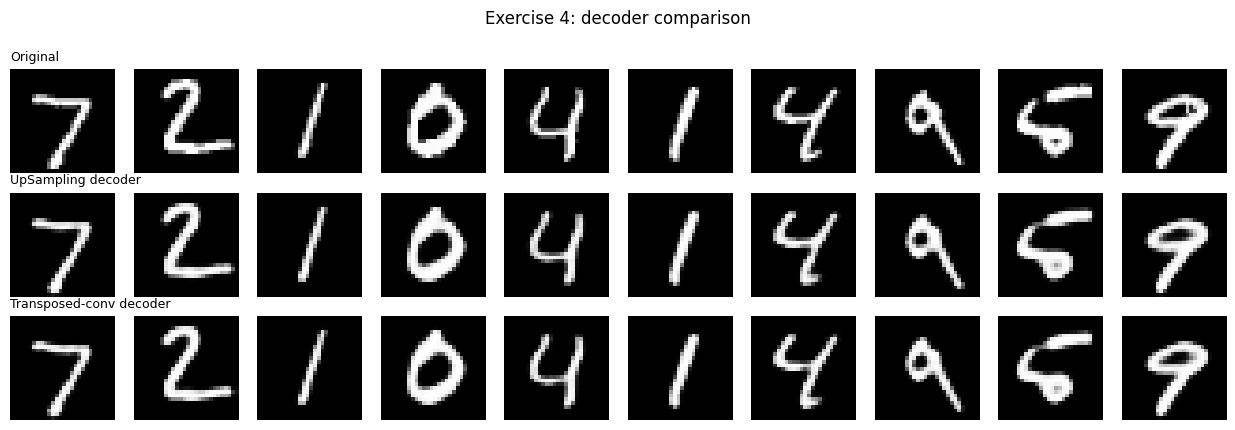

In [ ]:
cae_t = build_cae(decoder="transpose"); h_t, t_t = train(cae_t, x_tr, x_tr); xh_t = predict(cae_t, x_te)
ex4 = pd.DataFrame({"UpSampling2D + Conv": {**evaluate(x_te, xh_cae), "Parameters": cae.count_params()},
                    "Conv2DTranspose":     {**evaluate(x_te, xh_t),   "Parameters": cae_t.count_params()}}).T
display(ex4.round(5))
show_rows([x_te[idx10], xh_cae[idx10], xh_t[idx10]], ["Original", "UpSampling decoder", "Transposed-conv decoder"],
          suptitle="Exercise 4: decoder comparison")

,Reconstruction Loss,KL Loss,Total Loss,MSE,MAE,SSIM,Parameters
VAE z=2,152.33653,5.23594,157.57247,0.04545,0.10780,0.46263,284933.0
VAE z=8,100.11999,16.02662,116.14661,0.02234,0.05871,0.75309,304529.0


PCA explained variance of the 8-D latent means: [0.238 0.193]


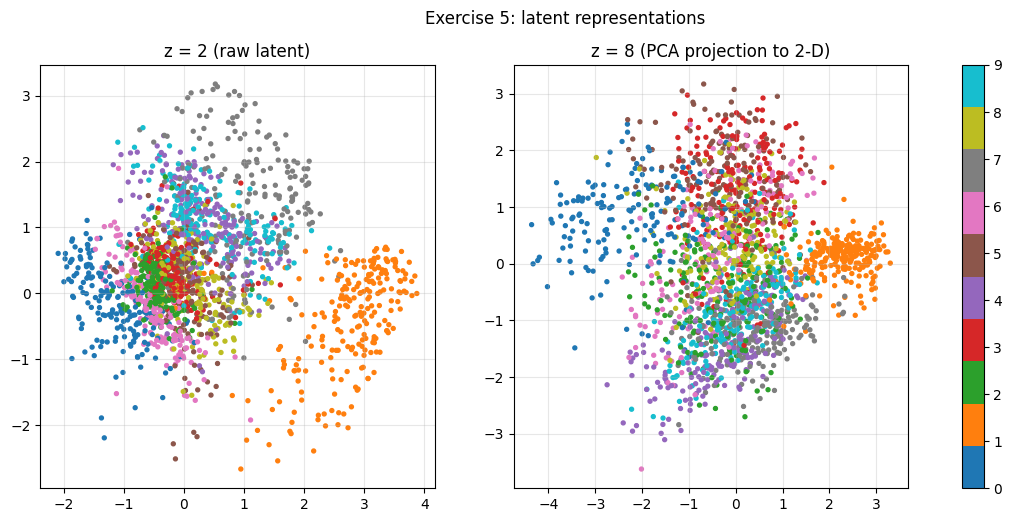

KL per latent dim (z=8): [0.609 2.585 2.057 2.223 2.272 2.104 1.921 2.255] | active dims (KL>0.1): 8


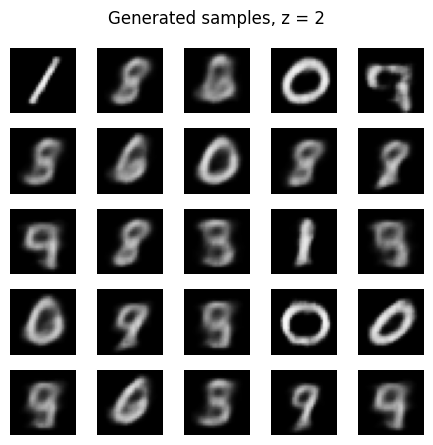

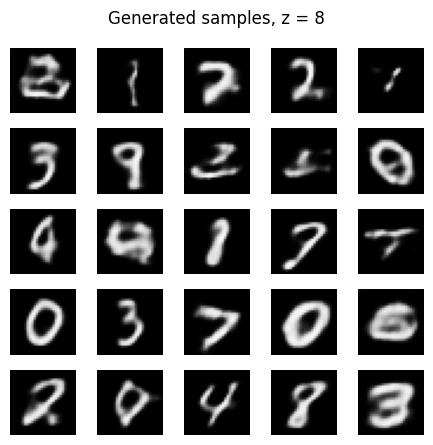

In [ ]:
vae8, hist_vae8, t_vae8 = train_vae(8, 1.0)
res8, xh8, mu8 = vae_evaluate(vae8)
ex5 = pd.DataFrame({"VAE z=2": {**vae_res, "Parameters": vae_params(vae)},
                    "VAE z=8": {**res8,    "Parameters": vae_params(vae8)}}).T
display(ex5.round(5))

# 8-D latent -> 2-D with PCA for visualisation
pca = PCA(2).fit(mu8); z8_2d = pca.transform(mu8)
print("PCA explained variance of the 8-D latent means:", pca.explained_variance_ratio_.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a, z, t in [(ax[0], mu_te, "z = 2 (raw latent)"), (ax[1], z8_2d, "z = 8 (PCA projection to 2-D)")]:
    sc = a.scatter(z[:, 0], z[:, 1], c=y_te, cmap="tab10", s=8); a.set_title(t); a.grid(alpha=.3)
plt.colorbar(sc, ax=ax, ticks=range(10)); plt.suptitle("Exercise 5: latent representations"); plt.show()

# per-dimension KL -> how many latent units are "active"
_, lv8 = encode(vae8, x_te)
kl_dim = np.mean(-0.5 * (1 + lv8 - mu8 ** 2 - np.exp(lv8)), axis=0)
print("KL per latent dim (z=8):", kl_dim.round(3), "| active dims (KL>0.1):", int((kl_dim > 0.1).sum()))

g2 = vae.decoder.predict(np.random.default_rng(3).standard_normal((25, 2)).astype("float32"), verbose=0)
g8 = vae8.decoder.predict(np.random.default_rng(3).standard_normal((25, 8)).astype("float32"), verbose=0)
show_grid(g2, 5, 5, "Generated samples, z = 2"); show_grid(g8, 5, 5, "Generated samples, z = 8")

,β,Reconstruction Loss,KL Loss,MSE,SSIM
0,0.1,152.1928,8.9705,0.0453,0.4687
1,1.0,151.4678,5.5595,0.0449,0.4691
2,4.0,151.3209,3.5647,0.0448,0.4604
3,10.0,159.7485,2.0960,0.0489,0.4119


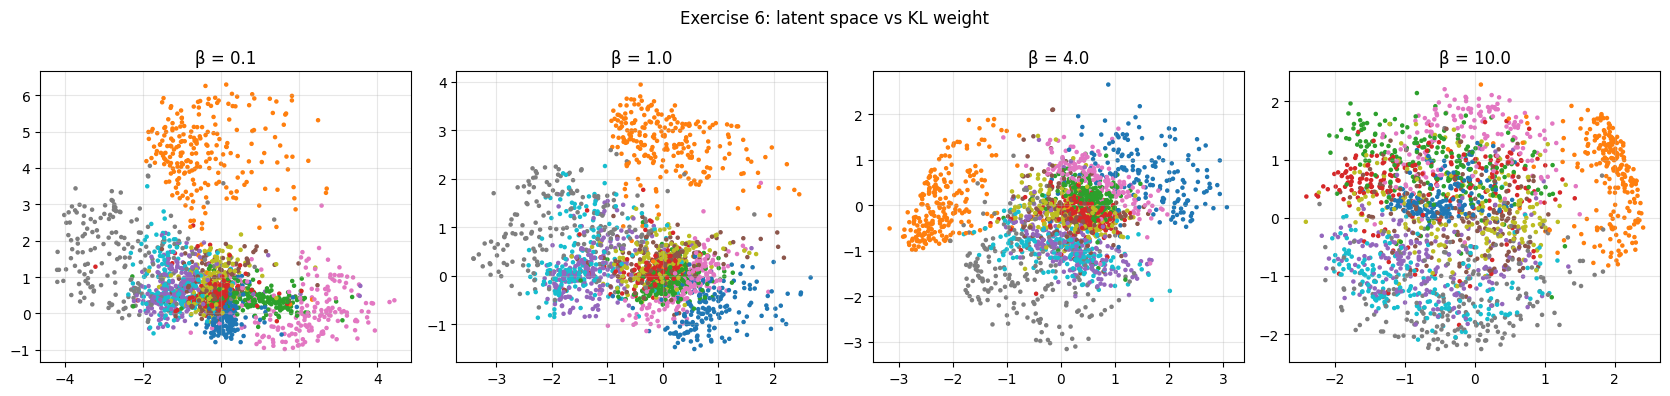

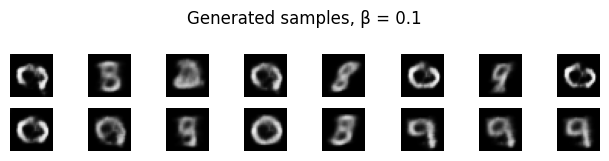

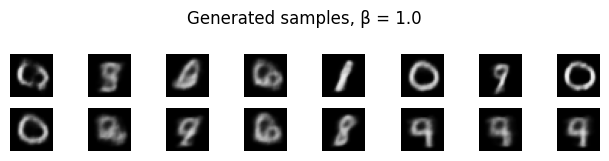

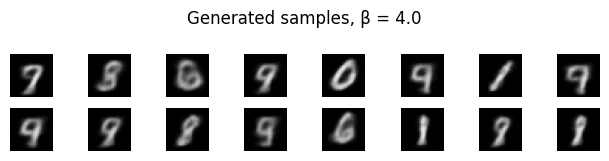

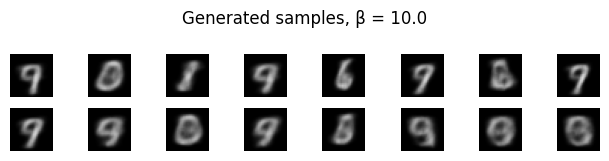

In [ ]:
betas = [0.1, 1.0, 4.0, 10.0]
ex6, vb = [], {}
for b in betas:
    v, h, t = train_vae(2, b); r, xh, mu = vae_evaluate(v)
    vb[b] = (v, mu); ex6.append({"β": b, "Reconstruction Loss": r["Reconstruction Loss"], "KL Loss": r["KL Loss"],
                                 "MSE": r["MSE"], "SSIM": r["SSIM"]})
display(pd.DataFrame(ex6).round(4))

fig, ax = plt.subplots(1, len(betas), figsize=(4.2 * len(betas), 4))
for a, b in zip(ax, betas):
    a.scatter(vb[b][1][:, 0], vb[b][1][:, 1], c=y_te, cmap="tab10", s=5); a.set_title(f"β = {b}"); a.grid(alpha=.3)
plt.suptitle("Exercise 6: latent space vs KL weight"); plt.tight_layout(); plt.show()
for b in betas:
    zz = np.random.default_rng(5).standard_normal((16, 2)).astype("float32")
    show_grid(vb[b][0].decoder.predict(zz, verbose=0), 2, 8, f"Generated samples, β = {b}", scale=0.8)

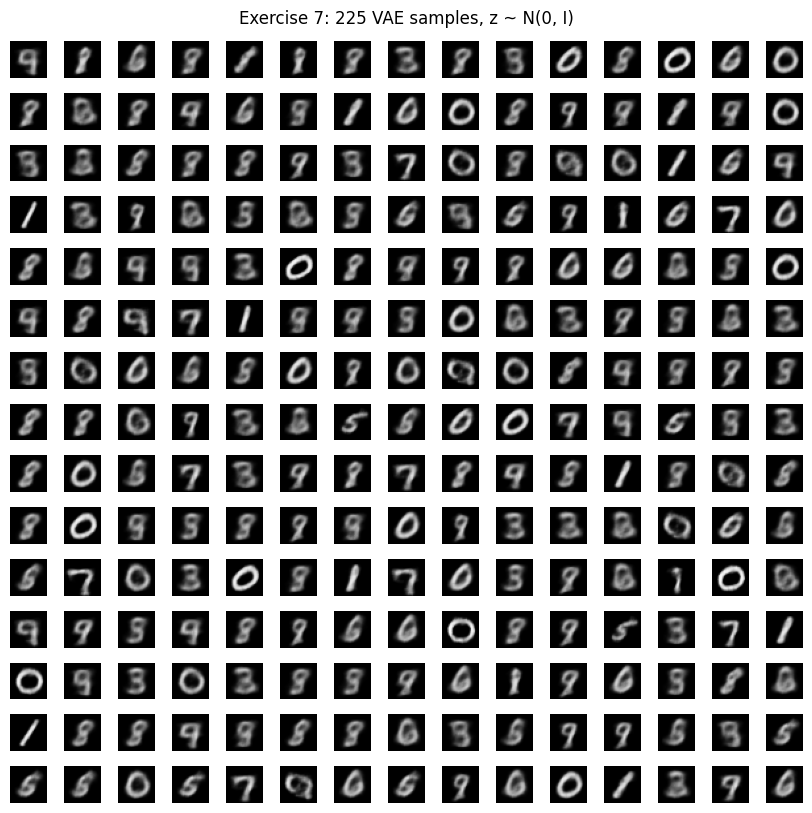

Classifier accuracy on real test digits: 0.9205


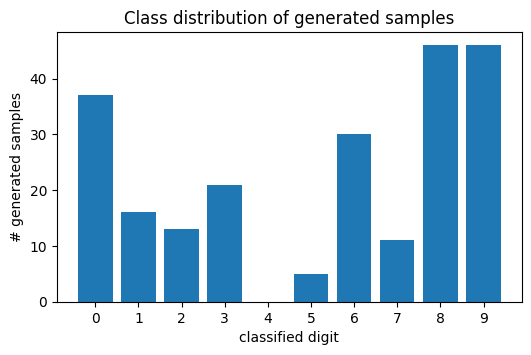

Mean classifier confidence: 0.714 | ambiguous samples (conf < 0.6): 64 / 225


In [ ]:
gen_big = vae.decoder.predict(np.random.default_rng(11).standard_normal((225, 2)).astype("float32"), verbose=0)
show_grid(gen_big, 15, 15, "Exercise 7: 225 VAE samples, z ~ N(0, I)", scale=0.55)

# quantify diversity with a small classifier trained on real MNIST
clf = keras.Sequential([keras.Input((28, 28, 1)), layers.Conv2D(16, 3, activation="relu"), layers.MaxPooling2D(),
                        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(), layers.Flatten(),
                        layers.Dense(10, activation="softmax")])
clf.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
clf.fit(x_tr, y_tr, epochs=3, batch_size=128, verbose=0)
print("Classifier accuracy on real test digits:", round(clf.evaluate(x_te, y_te, verbose=0)[1], 4))
p = clf.predict(gen_big, verbose=0); pred, conf = p.argmax(1), p.max(1)
plt.figure(figsize=(6, 3.5)); plt.bar(range(10), np.bincount(pred, minlength=10)); plt.xticks(range(10))
plt.xlabel("classified digit"); plt.ylabel("# generated samples"); plt.title("Class distribution of generated samples"); plt.show()
print(f"Mean classifier confidence: {conf.mean():.3f} | ambiguous samples (conf < 0.6): {(conf < 0.6).sum()} / {len(conf)}")

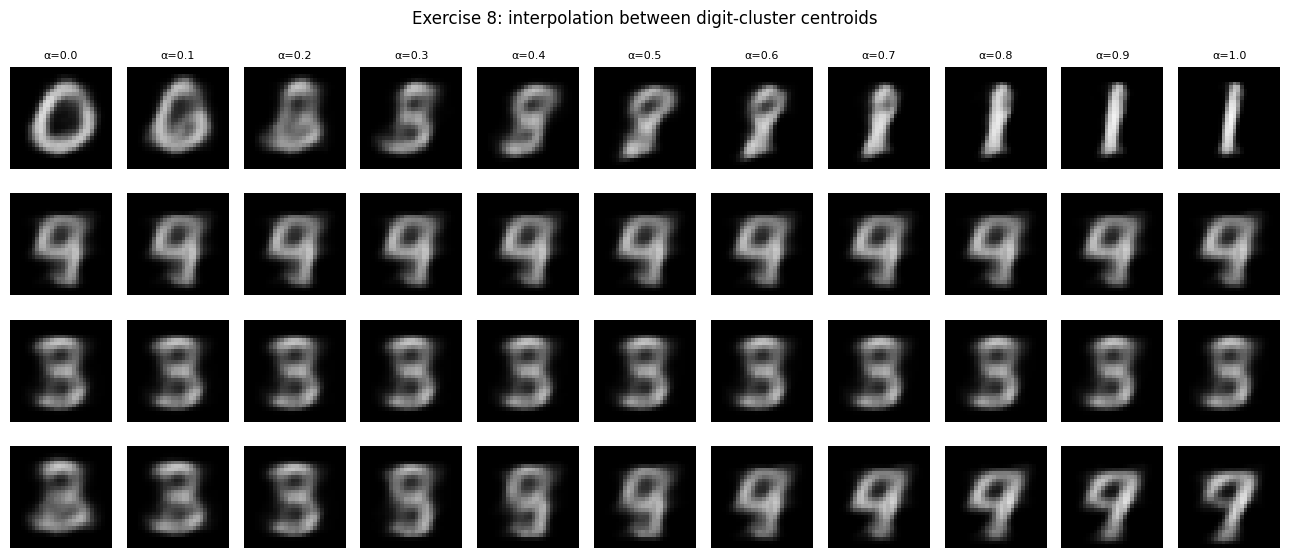

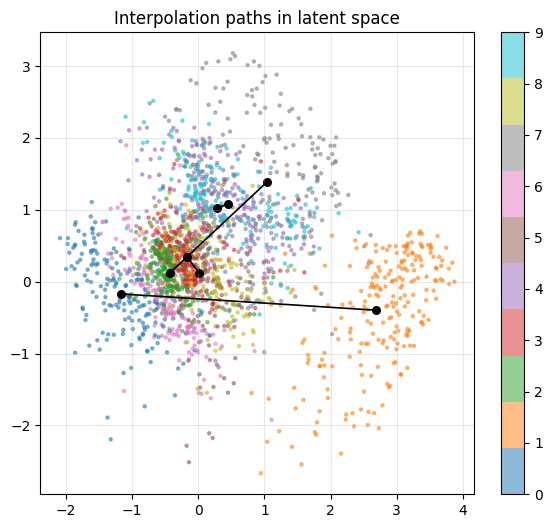

In [ ]:
centroids = {d: mu_te[y_te == d].mean(0) for d in range(10)}          # centre of each digit cluster
pairs8 = [(0, 1), (4, 9), (3, 5), (2, 7)]
fig, axes = plt.subplots(len(pairs8), 11, figsize=(13, 1.3 * len(pairs8) + 0.6))
for r, (a, b) in enumerate(pairs8):
    seq = interpolate(vae.decoder, centroids[a], centroids[b])
    for i in range(11):
        axes[r, i].imshow(seq[i].squeeze(), cmap="gray", vmin=0, vmax=1); axes[r, i].axis("off")
        if r == 0: axes[r, i].set_title(f"α={i/10:.1f}", fontsize=8)
    axes[r, 0].set_ylabel(f"{a}→{b}")
plt.suptitle("Exercise 8: interpolation between digit-cluster centroids"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
sc = plt.scatter(mu_te[:, 0], mu_te[:, 1], c=y_te, cmap="tab10", s=5, alpha=.5)
for a, b in pairs8:
    plt.plot(*zip(centroids[a], centroids[b]), "k-", lw=1.2); plt.scatter(*zip(centroids[a], centroids[b]), c="k", s=30)
plt.colorbar(sc, ticks=range(10)); plt.title("Interpolation paths in latent space"); plt.grid(alpha=.3); plt.show()

In [ ]:

final = pd.DataFrame(results).T.loc[["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE"]]
final = final[["MSE", "MAE", "SSIM", "Parameters", "Time (s)"]]
final["Parameters"] = final["Parameters"].astype(int)
display(final.round(5))
print("Denoising CAE: evaluated on Gaussian σ=0.2 noisy inputs vs clean targets.")
print("VAE: MSE/MAE/SSIM from the deterministic reconstruction decoder(μ(x)).")
final.to_csv("experiment7_results.csv")

,MSE,MAE,SSIM,Parameters,Time (s)
FC Autoencoder,0.02135,0.05661,0.74943,211040,12.6
Conv. Autoencoder,0.00259,0.01499,0.97397,74497,20.7
Denoising CAE,0.00448,0.02083,0.94659,74497,22.9
VAE,0.04545,0.10780,0.46263,284933,25.5


Denoising CAE: evaluated on Gaussian σ=0.2 noisy inputs vs clean targets.
VAE: MSE/MAE/SSIM from the deterministic reconstruction decoder(μ(x)).
